In [1]:
# ===============================
# 1. Import Required Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

In [4]:
# ===============================
# 2. Load Dataset
# ===============================

file_path = "black_milk_manchester_sales_profit_demographics_2019_2022.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4, 9)


,Year,Total_Sales_GBP,Total_Profit_GBP,Online_Sales_Percentage,InStore_Sales_Percentage,Primary_Age_Group,Top_Gender,Local_Customers_Percentage,Tourist_Customers_Percentage
0,2019,1250000,275000,58,42,18-25,Female,72,28
1,2020,980000,190000,76,24,18-25,Female,81,19
2,2021,1430000,310000,69,31,18-30,Female,75,25
3,2022,1680000,420000,63,37,18-30,Female,70,30


In [8]:
# ===============================
# 3. Data Cleaning (Final Correct Version)
# ===============================

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Convert types
df["year"] = df["year"].astype(int)
df["total_sales_gbp"] = df["total_sales_gbp"].astype(float)
df["total_profit_gbp"] = df["total_profit_gbp"].astype(float)

# Compute cost (since it doesn't exist)
df["cost"] = df["total_sales_gbp"] - df["total_profit_gbp"]

# Compute profit margin
df["profit_margin"] = df["total_profit_gbp"] / df["total_sales_gbp"]

# Keep only required years
df = df[df["year"].isin([2019, 2020, 2021, 2022])]

print("Cleaned Dataset Shape:", df.shape)
df.head()

Cleaned Dataset Shape: (4, 11)


,year,total_sales_gbp,total_profit_gbp,online_sales_percentage,instore_sales_percentage,primary_age_group,top_gender,local_customers_percentage,tourist_customers_percentage,cost,profit_margin
0,2019,1250000.0,275000.0,58,42,18-25,Female,72,28,975000.0,0.220000
1,2020,980000.0,190000.0,76,24,18-25,Female,81,19,790000.0,0.193878
2,2021,1430000.0,310000.0,69,31,18-30,Female,75,25,1120000.0,0.216783
3,2022,1680000.0,420000.0,63,37,18-30,Female,70,30,1260000.0,0.250000


In [11]:
print(df.columns)

Index(['year', 'total_sales_gbp', 'total_profit_gbp',
       'online_sales_percentage', 'instore_sales_percentage',
       'primary_age_group', 'top_gender', 'local_customers_percentage',
       'tourist_customers_percentage', 'cost', 'profit_margin'],
      dtype='object')


In [13]:
df.head()

,year,total_sales_gbp,total_profit_gbp,online_sales_percentage,instore_sales_percentage,primary_age_group,top_gender,local_customers_percentage,tourist_customers_percentage,cost,profit_margin
0,2019,1250000.0,275000.0,58,42,18-25,Female,72,28,975000.0,0.220000
1,2020,980000.0,190000.0,76,24,18-25,Female,81,19,790000.0,0.193878
2,2021,1430000.0,310000.0,69,31,18-30,Female,75,25,1120000.0,0.216783
3,2022,1680000.0,420000.0,63,37,18-30,Female,70,30,1260000.0,0.250000


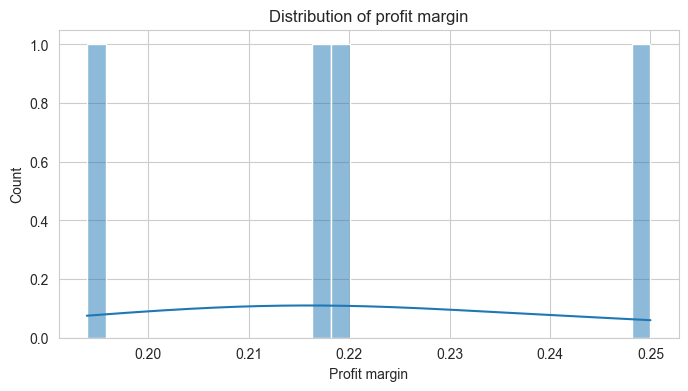

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df["profit_margin"], bins=30, kde=True)
plt.title("Distribution of profit margin")
plt.xlabel("Profit margin")
plt.show()

In [17]:
print(df.columns)
print(df.head())

Index(['year', 'total_sales_gbp', 'total_profit_gbp',
       'online_sales_percentage', 'instore_sales_percentage',
       'primary_age_group', 'top_gender', 'local_customers_percentage',
       'tourist_customers_percentage', 'cost', 'profit_margin'],
      dtype='object')
   year  total_sales_gbp  total_profit_gbp  online_sales_percentage  \
0  2019        1250000.0          275000.0                       58   
1  2020         980000.0          190000.0                       76   
2  2021        1430000.0          310000.0                       69   
3  2022        1680000.0          420000.0                       63   

   instore_sales_percentage primary_age_group top_gender  \
0                        42             18-25     Female   
1                        24             18-25     Female   
2                        31             18-30     Female   
3                        37             18-30     Female   

   local_customers_percentage  tourist_customers_percentage       co

In [19]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [27]:
print(df.columns)

Index(['Year', 'Total_Sales_GBP', 'Total_Profit_GBP',
       'Online_Sales_Percentage', 'InStore_Sales_Percentage',
       'Primary_Age_Group', 'Top_Gender', 'Local_Customers_Percentage',
       'Tourist_Customers_Percentage'],
      dtype='object')


In [31]:
print(df.index)

RangeIndex(start=0, stop=4, step=1)


In [32]:
print(df.columns)

Index(['Year', 'Total_Sales_GBP', 'Total_Profit_GBP',
       'Online_Sales_Percentage', 'InStore_Sales_Percentage',
       'Primary_Age_Group', 'Top_Gender', 'Local_Customers_Percentage',
       'Tourist_Customers_Percentage'],
      dtype='object')


In [33]:
print(df.head())
print(df.columns)

   Year  Total_Sales_GBP  Total_Profit_GBP  Online_Sales_Percentage  \
0  2019          1250000            275000                       58   
1  2020           980000            190000                       76   
2  2021          1430000            310000                       69   
3  2022          1680000            420000                       63   

   InStore_Sales_Percentage Primary_Age_Group Top_Gender  \
0                        42             18-25     Female   
1                        24             18-25     Female   
2                        31             18-30     Female   
3                        37             18-30     Female   

   Local_Customers_Percentage  Tourist_Customers_Percentage  
0                          72                            28  
1                          81                            19  
2                          75                            25  
3                          70                            30  
Index(['Year', 'Total_Sales_GBP',

In [39]:
print(df.columns)

Index(['Year', 'Total_Sales_GBP', 'Total_Profit_GBP',
       'Online_Sales_Percentage', 'InStore_Sales_Percentage',
       'Primary_Age_Group', 'Top_Gender', 'Local_Customers_Percentage',
       'Tourist_Customers_Percentage'],
      dtype='object')


In [42]:
print(df.columns.tolist())

['Year', 'Total_Sales_GBP', 'Total_Profit_GBP', 'Online_Sales_Percentage', 'InStore_Sales_Percentage', 'Primary_Age_Group', 'Top_Gender', 'Local_Customers_Percentage', 'Tourist_Customers_Percentage']


In [43]:
[c for c in df.columns if "purch" in c.lower()]

[]

In [44]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Year', 'Total_Sales_GBP', 'Total_Profit_GBP', 'Online_Sales_Percentage', 'InStore_Sales_Percentage', 'Primary_Age_Group', 'Top_Gender', 'Local_Customers_Percentage', 'Tourist_Customers_Percentage']


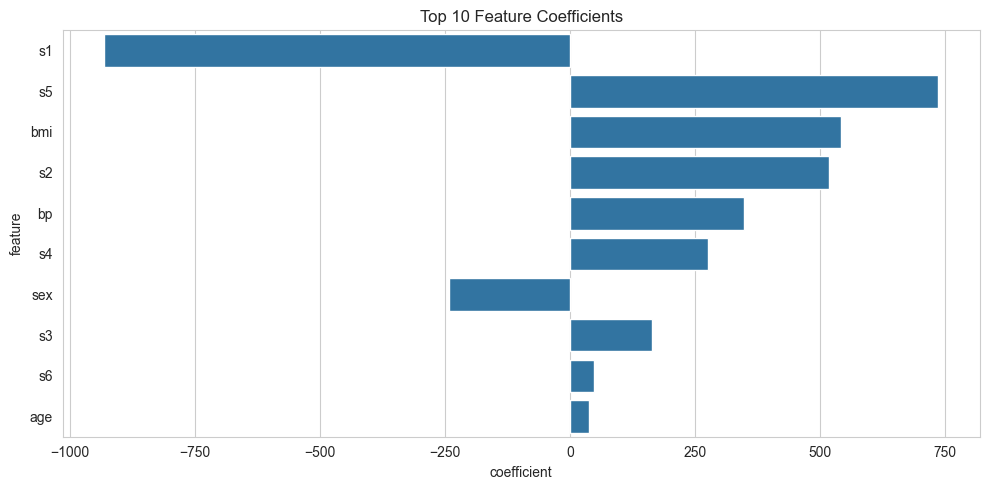

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load sample dataset
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

coef_df = coef_df.reindex(
    coef_df["coefficient"].abs().sort_values(ascending=False).index
)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(data=coef_df.head(10), x="coefficient", y="feature")
plt.title("Top 10 Feature Coefficients")
plt.tight_layout()
plt.show()

In [50]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.6f}")
print(f"Test R^2: {r2:.4f}")

Test MSE: 2900.193628
Test R^2: 0.4526
